## PyTorch In Class Practice

### Problem 1: Implementing an objective function in NumPy and PyTorch
Implement two Python functions that implements the mathematical functions $f(x) = 3x^\intercal x - x_1 - 4$. One function should work for $x$ a `numpy.ndarray` and the other should work for $x$ a `torch.FloatTensor`.

In [1]:
import torch
import numpy as np


def f_numpy(x):
    # YOUR CODE HERE
    raise NotImplementedError()


def f_torch(x):
    # YOUR CODE HERE
    raise NotImplementedError()

In [ ]:
assert abs(f_numpy(np.zeros(4)) + 4) < 1e-6
assert abs(f_numpy(np.ones(2)) - 1) < 1e-6

assert abs(f_torch(torch.zeros(4)) + 4) < 1e-6
assert abs(f_torch(torch.ones(2)) - 1) < 1e-6

x0 = (1, -2, 3, 4, 5)
assert abs(f_numpy(np.array(x0)) - f_torch(torch.Tensor(x0))) < 1e-6

### Problem 2: Computing gradients manually and automatically
Implement functions to compute the gradient of $f$ at $x$ using numpy and PyTorch. Use autodiff for the latter.

In [ ]:
def f_grad_numpy(x):
    # YOUR CODE HERE
    raise NotImplementedError()


def f_grad_torch(x):
    # YOUR CODE HERE
    raise NotImplementedError()

In [ ]:
def finite_diff(x, v):
    return (f_numpy(x + v) - f_numpy(x - v)) / (2 * np.linalg.norm(v))


x = np.ones(2)
v0 = 1e-4 * np.array([1, 0])
assert abs(finite_diff(x, v0) - f_grad_numpy(x)[0]) < 1e-2
v1 = 1e-4 * np.array([0, 1])
assert abs(finite_diff(x, v1) - f_grad_numpy(x)[1]) < 1e-2

np.random.seed(42)
for i in range(10):
    x2 = np.random.randn(5)
    v2 = np.random.randn(5)
    v2 = v2 / np.linalg.norm(v2)
    observed = finite_diff(x2, 1e-4 * v2)
    derived_vec = f_grad_numpy(x2)
    derived = derived_vec.dot(v2)
    assert abs(observed - derived) < 1e-2

xt = torch.tensor(x, requires_grad=True)
diff = f_grad_torch(xt).numpy() - f_grad_numpy(x)
assert np.linalg.norm(diff) < 1e-6

### Problem 3: Minimizing our function with gradient descent
Write a function that minimizes $f$ using gradient descent, by calling by calling `f_torch`. The function should take two arguments: an initial iterate `x0` and a number of gradient descent iterations `num_iters`. It should return the minimizer.

In [ ]:
def minimize(x0, num_iters, step_size=0.1):
    x = x0.clone()
    x.requires_grad_(True)
    for i in range(num_iters):
        y = f_torch(x)
        y.backward()
        with torch.no_grad():
            x -= step_size * x.grad
            x.grad.zero()
    return x
    # end solution

In [ ]:
x_opt = minimize(torch.zeros(3), 30)
assert (x_opt - torch.Tensor([0.1667, 0.0000, 0.0000])).norm() < 1e-3

### Problem 4: Working with PyTorch datasets
Find the mean brightness of CIFAR-10 images by iterating through the dataset and summing the pixel intensities.

In [1]:
from torchvision import datasets
import torchvision.transforms as transforms


trainset = datasets.CIFAR10(root='./data',
                            train=True,
                            download=True,
                            transform=transforms.ToTensor())

100%|██████████| 170M/170M [00:03<00:00, 45.3MB/s]


Extracting ./data/cifar-10-python.tar.gz to ./data


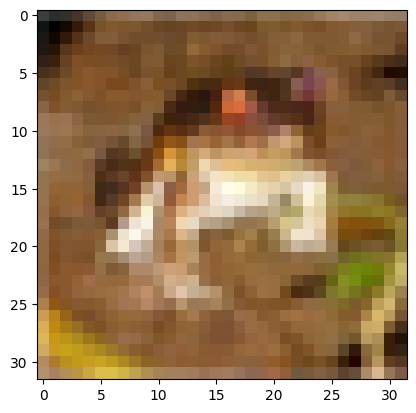

In [4]:
from matplotlib import pyplot as plt


def imshow(img):
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


for img, label in trainset:
    imshow(img)
    break

In [ ]:
def mean_brightness_directly(dataset):
    # YOUR CODE HERE
    raise NotImplementedError()

In [ ]:
assert abs(mean_brightness_directly(trainset) - 0.4733) < 1e-4

### Problem 5: Data loaders
Find the mean brightness of CIFAR-10 images by iterating through the dataset using a DataLoader with a batch size of 256.

In [ ]:
from torch.utils.data import DataLoader


def mean_brightness_dataloader(dataset):
    loader = DataLoader(trainset, batch_size=256, shuffle=True)
    # YOUR CODE HERE
    raise NotImplementedError()

In [ ]:
assert abs(mean_brightness_dataloader(trainset) - 0.4733) < 1e-4

### Problem 6: Minimizing a loss function using SGD
Find the mean brightness of CIFAR-10 images in two ways: by iterating through the dataset and summing the pixel intensities and with stochastic gradient descent, by minimizing squared error.

In [ ]:
def mean_brightness_sgd(dataset):
    loader = DataLoader(trainset, batch_size=256, shuffle=True)
    cur_mean = torch.zeros(1)
    cur_mean.requires_grad_(True)
    # YOUR CODE HERE
    raise NotImplementedError()

    return cur_mean.data.item()

In [ ]:
assert abs(mean_brightness_sgd(trainset) - 0.4733) < 1e-2